In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcaHBcRGVza3RvcFxwdWJfcG9ydFxweS1xdWFydG9cQWRleWV5ZS1Kb3NlcGgtU2V5aXNvblxibG9nXEdTUy1BbmFseXNpcw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\hp\\anaconda3\\Lib\\importlib\\_bootstrap.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\importlib\\_bootstrap_external.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\zipimport.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\codecs.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\aliases.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\__init__.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\utf_8.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\cp1252.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\abc.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\io.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\stat.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\_collections_abc.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\genericpath.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\ntpath.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\os.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\_sitebu

In [2]:
# firstly we import the needed modules/libraries:

import pandas as pd 
import numpy as np 
from pandas import read_csv
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
from statsmodels.graphics.mosaicplot import mosaic
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Read in the dataset:

df = pd.read_csv("C:\\Users\\hp\\Desktop\\python\\projects\\gss_sub.csv")
df

,year,id,labor_status,self_employed,marital_status,n_siblings,age,high_school,degree,political_affiliation,environment,law_enforcement,drugs,space_exploration,inequality,household_size
0,1972.0,1.0,WORKING FULLTIME,SOMEONE ELSE,NEVER MARRIED,3.0,23.0,16.0,BACHELOR,"IND,NEAR DEM",IAP,IAP,IAP,IAP,NaN,1.0
1,1972.0,2.0,RETIRED,SOMEONE ELSE,MARRIED,4.0,70.0,10.0,LT HIGH SCHOOL,NOT STR DEMOCRAT,IAP,IAP,IAP,IAP,NaN,2.0
2,1972.0,3.0,WORKING PARTTIME,SOMEONE ELSE,MARRIED,5.0,48.0,12.0,HIGH SCHOOL,INDEPENDENT,IAP,IAP,IAP,IAP,NaN,4.0
3,1972.0,4.0,WORKING FULLTIME,SOMEONE ELSE,MARRIED,5.0,27.0,17.0,BACHELOR,NOT STR DEMOCRAT,IAP,IAP,IAP,IAP,NaN,2.0
4,1972.0,5.0,KEEPING HOUSE,SOMEONE ELSE,MARRIED,2.0,61.0,12.0,HIGH SCHOOL,STRONG DEMOCRAT,IAP,IAP,IAP,IAP,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59594,2014.0,2539.0,KEEPING HOUSE,SOMEONE ELSE,WIDOWED,6.0,89.0,14.0,JUNIOR COLLEGE,NOT STR REPUBLICAN,TOO LITTLE,TOO LITTLE,TOO LITTLE,IAP,NaN,1.0
59595,2014.0,2540.0,WORKING FULLTIME,SOMEONE ELSE,DIVORCED,3.0,56.0,12.0,HIGH SCHOOL,INDEPENDENT,TOO LITTLE,TOO LITTLE,TOO MUCH,IAP,NaN,1.0
59596,2014.0,2541.0,WORKING FULLTIME,SOMEONE ELSE,NEVER MARRIED,5.0,24.0,14.0,HIGH SCHOOL,"IND,NEAR DEM",TOO LITTLE,ABOUT RIGHT,ABOUT RIGHT,IAP,NaN,3.0
59597,2014.0,2542.0,WORKING FULLTIME,SOMEONE ELSE,NEVER MARRIED,2.0,27.0,13.0,HIGH SCHOOL,NOT STR DEMOCRAT,IAP,IAP,IAP,IAP,NaN,2.0


In [4]:
# Taking an overview of the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59599 entries, 0 to 59598
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   59599 non-null  float64
 1   id                     59599 non-null  float64
 2   labor_status           59583 non-null  object 
 3   self_employed          59306 non-null  object 
 4   marital_status         59575 non-null  object 
 5   n_siblings             56682 non-null  float64
 6   age                    59599 non-null  float64
 7   high_school            59440 non-null  float64
 8   degree                 59464 non-null  object 
 9   political_affiliation  59257 non-null  object 
 10  environment            59388 non-null  object 
 11  law_enforcement        59378 non-null  object 
 12  drugs                  59380 non-null  object 
 13  space_exploration      59596 non-null  object 
 14  inequality             1532 non-null   float64
 15  ho

In [5]:
# inspecting individual cat cols :

df.describe(include='object')

,labor_status,self_employed,marital_status,degree,political_affiliation,environment,law_enforcement,drugs,space_exploration
count,59583,59306,59575,59464,59257,59388,59378,59380,59596
unique,8,4,5,6,9,5,5,5,5
top,WORKING FULLTIME,SOMEONE ELSE,MARRIED,HIGH SCHOOL,NOT STR DEMOCRAT,IAP,IAP,IAP,IAP
freq,29437,49497,31919,30556,12446,38143,38143,38143,59115


In [6]:
# inspecting single col :

df["environment"].value_counts(normalize=True) * 100

environment
IAP            64.226780
TOO LITTLE     22.198087
ABOUT RIGHT     9.168519
TOO MUCH        2.859163
DK              1.547451
Name: proportion, dtype: float64

In [7]:
# create a dict of columns and data type mapping

dict_conversion = {k: "category" for k in df.select_dtypes(include="object").columns}
dict_conversion 

# convert using the astype method:

df = df.astype(dict_conversion)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59599 entries, 0 to 59598
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   year                   59599 non-null  float64 
 1   id                     59599 non-null  float64 
 2   labor_status           59583 non-null  category
 3   self_employed          59306 non-null  category
 4   marital_status         59575 non-null  category
 5   n_siblings             56682 non-null  float64 
 6   age                    59599 non-null  float64 
 7   high_school            59440 non-null  float64 
 8   degree                 59464 non-null  category
 9   political_affiliation  59257 non-null  category
 10  environment            59388 non-null  category
 11  law_enforcement        59378 non-null  category
 12  drugs                  59380 non-null  category
 13  space_exploration      59596 non-null  category
 14  inequality             1532 non-null  

In [8]:
# inspecting a single cat col levels:
df["labor_status"].cat.categories

Index(['KEEPING HOUSE', 'OTHER', 'RETIRED', 'SCHOOL', 'TEMP NOT WORKING',
       'UNEMPL, LAID OFF', 'WORKING FULLTIME', 'WORKING PARTTIME'],
      dtype='object')

In [9]:
# create a dict to collapse: 

new_labour_status = {'UNEMPL, LAID OFF' : 'UNEMPLOYED',
                    'TEMP NOT WORKING': 'UNEMPLOYED', 
                     'WORKING FULLTIME' : 'EMPLOYED', 
                     'WORKING PARTTIME' :  'EMPLOYED'
                     }

# Replace the values in the column and reset as a category: 

df["labour_status_clean"] = (
    df["labor_status"]
    .astype(str)
    .replace(new_labour_status)
    .astype("category")
)

# preview new col : 

df["labour_status_clean"].value_counts(normalize=True)

labour_status_clean
EMPLOYED         0.596520
KEEPING HOUSE    0.161915
RETIRED          0.135942
UNEMPLOYED       0.054196
SCHOOL           0.030890
OTHER            0.020269
nan              0.000268
Name: proportion, dtype: float64

In [10]:
# inspecting vars or cols with same cat levels/encoding: 
print(df.environment.cat.categories)

print(df.drugs.cat.categories)

print(df.law_enforcement.cat.categories)

Index(['ABOUT RIGHT', 'DK', 'IAP', 'TOO LITTLE', 'TOO MUCH'], dtype='object')
Index(['ABOUT RIGHT', 'DK', 'IAP', 'TOO LITTLE', 'TOO MUCH'], dtype='object')
Index(['ABOUT RIGHT', 'DK', 'IAP', 'TOO LITTLE', 'TOO MUCH'], dtype='object')


In [11]:
# Re-ordering cat vars : 

# Set the new order: 
new_order = ['TOO LITTLE', 'TOO MUCH', 'ABOUT RIGHT','DK', 'IAP']

cat_to_remove = ['DK', 'IAP']

# loop through each col : 
for col in ["environment","law_enforcement", "drugs"]:
    # reorder and remove the categories
    df[col + "_clean"] = df[col].cat.reorder_categories(new_order, ordered=True)
    df[col + "_clean"] = df[col + "_clean"].cat.remove_categories(cat_to_remove)

# preview of the col's categories
df["environment_clean"].cat.categories

Index(['TOO LITTLE', 'TOO MUCH', 'ABOUT RIGHT'], dtype='object')

In [12]:
df["degree"].cat.categories.tolist()

['BACHELOR',
 'DK',
 'GRADUATE',
 'HIGH SCHOOL',
 'JUNIOR COLLEGE',
 'LT HIGH SCHOOL']

In [13]:
# defining a dict to map old degree levels to new ones:

new_degree = {'LT HIGH SCHOOL' : 'HIGH SCHOOL',
               'BACHELOR' : 'COLLEGE/UNIVERSITY', 
                'GRADUATE' : 'COLLEGE/UNIVERSITY',
              'JUNIOR COLLEGE': 'COLLEGE/UNIVERSITY'
             }


# replace old degree categories with new ones and convert to categorical:

df["degree_clean"] = df["degree"].astype(str).replace(new_degree).astype("category")


# Remove  the 'DK' level from the new degree col:
df["degree_clean"] = (
    df["degree_clean"]
    .cat.remove_categories(['DK'])
)



# Re-ordered the degree_clean levels and set as ordered: 

df["degree_clean"] = pd.Categorical(
    df["degree_clean"],
    categories=['HIGH SCHOOL', 'COLLEGE/UNIVERSITY'],
    ordered=True
)

# preview the new col 

df["degree_clean"].value_counts(normalize=True)

degree_clean
HIGH SCHOOL           0.732796
COLLEGE/UNIVERSITY    0.267204
Name: proportion, dtype: float64

In [14]:
# binning date var/col along decade lines: 

df["year"] = df["year"].astype("Int64")

decade_boundaries = [(1970, 1979), (1979, 1989),(1989, 1999), (1999, 2009), (2009, 2019)]

decade_labels = ["1970s", "1980s", "1990s", "2000s", "2010s"]

# set the bins and cut the Dataframe: 
bins = pd.IntervalIndex.from_tuples(decade_boundaries)
df["decade"] = pd.cut(df["year"], bins)


# rename the newly created decade col 
df["decade"] = df["decade"].cat.rename_categories(decade_labels)


# preview new col 

df[["year", "decade"]]

,year,decade
0,1972,1970s
1,1972,1970s
2,1972,1970s
3,1972,1970s
4,1972,1970s
...,...,...
59594,2014,2010s
59595,2014,2010s
59596,2014,2010s
59597,2014,2010s


In [15]:
# visualizing categorical var: 

fig = px.bar(df["labour_status_clean"].value_counts(), 
                template = "plotly_white", 
            labels={"labour_status_clean": "Labour Status", 
             "value":"Count of Respondents"})


# update the layout 
fig.update_layout(showlegend=False)

fig.show()

In [16]:
# visualizing categorical vars: making adjustments to our first plot

fig = px.bar(df["labour_status_clean"].value_counts(ascending=True), 
                template = "plotly_white", 
              orientation ="h", 
              title="Labour Status by Respondents", 
              labels={"labour_status_clean": "Labour Status", 
             "value":"Count of Respondents"})


# update the layout
fig.update_layout(showlegend=False)

fig.show()

In [17]:
# showing categorical averages : 

household_by_decade = df.groupby(["decade", "degree_clean"], as_index=False)["household_size"].mean().round(2)
household_by_decade

,decade,degree_clean,household_size
0,1970s,HIGH SCHOOL,3.27
1,1970s,COLLEGE/UNIVERSITY,3.03
2,1980s,HIGH SCHOOL,2.77
3,1980s,COLLEGE/UNIVERSITY,2.61
4,1990s,HIGH SCHOOL,2.57
5,1990s,COLLEGE/UNIVERSITY,2.49
6,2000s,HIGH SCHOOL,2.50
7,2000s,COLLEGE/UNIVERSITY,2.40
8,2010s,HIGH SCHOOL,2.47
9,2010s,COLLEGE/UNIVERSITY,2.30


In [18]:
# visualize the result: 

fig = px.bar(household_by_decade, 
            x="decade", 
            y="household_size", 
             color = "degree_clean",
             barmode ="group",
            template = "plotly_white", 
            title="Average Household Size by Decade", 
            labels={"household_size": "Household Size", 
             "decade":"Decade"})

fig.show()

In [19]:
# visualizing using a boxplot: 
fig = px.box(df, 
            x="age", 
            y="labour_status_clean", 
            title="Age Distribution by Labour Status", 
            labels={"age": "Age", 
             "labour_status_clean":"Labour Status"})


fig.show()

In [20]:
# we can use a frequency table to show this relatiobship to get a overview of such relatiobship #between the two vars 

pd.crosstab(df["degree_clean"], df["law_enforcement_clean"])

law_enforcement_clean,TOO LITTLE,TOO MUCH,ABOUT RIGHT
degree_clean,,,
HIGH SCHOOL,8063,1340,4879
COLLEGE/UNIVERSITY,3230,428,2635


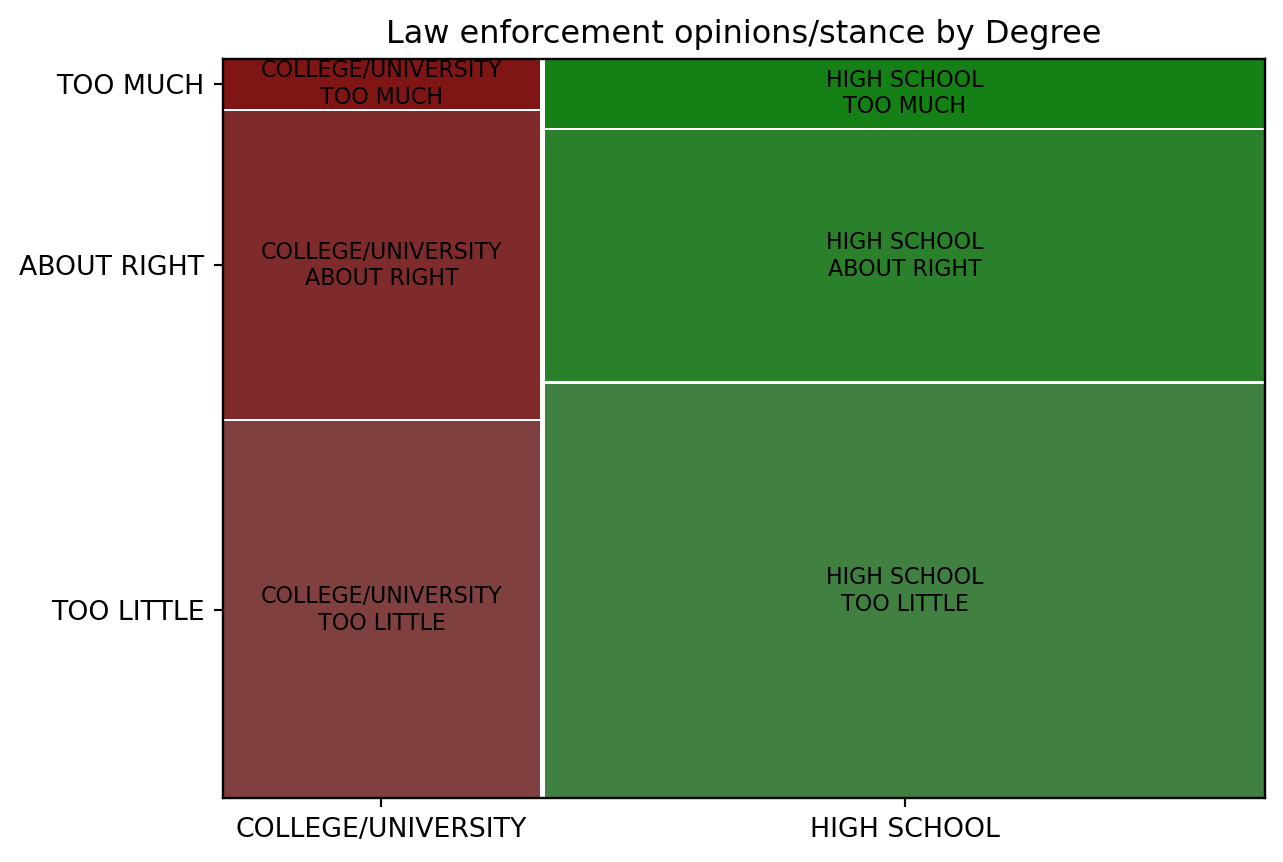

In [21]:
# using a mosaic plot to show result: 
# mosaic plot enables one to show the relationship between two categorical variables: it helps #to #give a sense of proportions between cat vars

mosaic(df, ["degree_clean", "law_enforcement_clean"], 
       title="Law enforcement opinions/stance by Degree")

plt.show()

In [22]:
# visualizing marital rates using line chart:

marital_rates = df.groupby(["year"], as_index=False)["marital_status"].value_counts(normalize=True)
marital_rates

,year,marital_status,proportion
0,1972,MARRIED,0.719157
1,1972,NEVER MARRIED,0.130192
2,1972,WIDOWED,0.086175
3,1972,DIVORCED,0.040298
4,1972,SEPARATED,0.024179
...,...,...,...
145,2014,MARRIED,0.456985
146,2014,NEVER MARRIED,0.266377
147,2014,DIVORCED,0.162194
148,2014,WIDOWED,0.082478


In [23]:
# showing the marital rates by a line chart:

fig = px.line(marital_rates, 
             x="year", 
             y="proportion",
              template= "plotly_white",
              color= "marital_status",
             title="Marital Rates by Year")

# update for right tick format:
fig.update_yaxes(tickformat=".0%")

fig.show()

In [24]:
# aggreation for education rates:

education_rates = df.groupby(["year"], as_index=False)["degree_clean"].value_counts(normalize=True)
education_rates.head()

,year,degree_clean,proportion
0,1972,HIGH SCHOOL,0.878616
1,1972,COLLEGE/UNIVERSITY,0.121384
2,1973,HIGH SCHOOL,0.854265
3,1973,COLLEGE/UNIVERSITY,0.145735
4,1974,HIGH SCHOOL,0.840189


In [25]:
# visualzing education rates via a line chart:

fig = px.line(education_rates, 
             x="year", 
             y="proportion",
              template= "plotly_white",
              color= "degree_clean",
             title="Education Rates by Year")

# update for right tick format:
fig.update_yaxes(tickformat=".0%")

fig.show()

In [26]:
# comparing education rates along the decade lines:

education_rates_2 = df.groupby(["decade"], as_index=False)["degree_clean"].value_counts(normalize=True)
education_rates_2

,decade,degree_clean,proportion
0,1970s,HIGH SCHOOL,0.848165
1,1970s,COLLEGE/UNIVERSITY,0.151835
2,1980s,HIGH SCHOOL,0.788369
3,1980s,COLLEGE/UNIVERSITY,0.211631
4,1990s,HIGH SCHOOL,0.706480
5,1990s,COLLEGE/UNIVERSITY,0.293520
6,2000s,HIGH SCHOOL,0.663669
7,2000s,COLLEGE/UNIVERSITY,0.336331
8,2010s,HIGH SCHOOL,0.635906
9,2010s,COLLEGE/UNIVERSITY,0.364094


In [27]:
# education rate along decade lines:

fig = px.line(education_rates_2, 
             x="decade", 
             y="proportion",
              template= "plotly_white",
              color= "degree_clean",
             title="Education Rates by Year")

# update for right tick format:
fig.update_yaxes(tickformat=".0%")

fig.show()